In [18]:
!pip install pyodbc pandas numpy matplotlib

In [30]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configuration de la connexion
conn = pyodbc.connect('DRIVER={ODBC Driver 18 for SQL Server};'
    'SERVER=localhost\SQLEXPRESS;' 
    'DATABASE=master;'
    'Trusted_Connection=yes;'
    'TrustServerCertificate=yes;')


query = "SELECT * FROM table_bilan"
df_bilan = pd.read_sql(query, conn)


print("Données du bilan importées avec succès :")
df_bilan.head(9) #head(9) car 9lignes en tout



Données du bilan importées avec succès :


,id,poste_bilan,categorie,montant_mde,maturite_mois,periodicite,taux,type_taux,loi_ecoulement
0,1,HQLA / Cash,ACTIF,90.0,1,1,0.0350,V,BULLET
1,2,Credit Habitat,ACTIF,450.0,240,1,0.0420,F,ACTUARIEL
2,3,Credit Equipement,ACTIF,250.0,60,3,0.0550,V,LINEAIRE
3,4,Credit Tresorerie,ACTIF,100.0,6,1,0.0450,F,LINEAIRE
4,5,Autre Actif (Titres),ACTIF,110.0,120,12,0.0300,F,BULLET
5,6,DAV Client Retail,PASSIF,480.0,120,1,0.0015,F,MIXTE
6,7,Compte Terme Client,PASSIF,120.0,24,24,0.0320,F,BULLET
7,8,Dettes Emises,PASSIF,300.0,72,72,0.0400,F,BULLET
8,9,Capitaux Propres,PASSIF,100.0,999,1,0.0000,F,STABLE


In [31]:
import numpy as np

# Configuration
horizon = 120  # horizon choisit pour le projet 10ans (120mois)
flux_dict = {}

for index, row in df_bilan.iterrows():
    nom = row['poste_bilan']
    montant = row['montant_mde']
    mat = int(row['maturite_mois'])
    per = int(row['periodicite'])
    loi = row['loi_ecoulement']
    cat = row['categorie']
    taux = float(row['taux'])
    
    flux = np.zeros(horizon)
    
# --- 1. LOI BULLET (HQLA / CASH ; Autre Actifs ; Compte à terme client ; Dettes émises) --- 
    if loi == 'BULLET':
        if mat <= horizon:
            flux[mat-1] = montant
            
# --- 2. LOI LINEAIRE (Crédit équipement ; Crédit trésorerie ) ---
    elif loi == 'LINEAIRE':
        nb_ech = mat // per
        mt_ech = montant / nb_ech
        for i in range(1, nb_ech + 1):
            m_f = i * per
            if m_f <= horizon:
                flux[m_f-1] = mt_ech
                
# --- 3. LOI ACTUARIEL (Crédit Habitat) ---
    elif loi == 'ACTUARIEL':
        tm = taux / 12
# Formule de la mensualité constante (Capital + Intérêt)
        mensualite = (montant * tm) / (1 - (1 + tm)**-mat)
        cr = montant
        for m in range(1, mat + 1):
            interet_m = cr * tm
            amortissement_m = mensualite - interet_m # On ne garde que le flux de capital
            if m <= horizon:
                flux[m-1] = amortissement_m
            cr -= amortissement_m
            
# --- 4. LOI MIXTE (DAV  client retail ; ) ---
    elif loi == 'MIXTE':
# 20% de fuite immédiate (mois 1), le reste s'écoule sur 10 ans
        part_volatile = 0.20
        flux[0] = montant * part_volatile
        restant = montant * (1 - part_volatile)
        amort_mensuel = restant / mat
        for m in range(1, mat + 1):
            if m <= horizon:
                flux[m-1] += amort_mensuel

# --- 5. LOI STABLE (Capitaux Propres) ---
    elif loi == 'STABLE':
# Pas de remboursement de capital pour les fonds propres
        pass 

# changement de signe au passif
    if cat == 'PASSIF':
        flux = -flux
        
    flux_dict[nom] = flux

# Création du DataFrame final
df_flux = pd.DataFrame(flux_dict).T
df_flux.columns = [f"M{i}" for i in range(1, horizon + 1)]

print("Moteur terminé. Voici l'aperçu des flux (12 premiers mois) :")
df_flux.iloc[:, :12]

Moteur terminé. Voici l'aperçu des flux (12 premiers mois) :


,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12
HQLA / Cash,90.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Credit Habitat,1.199568,1.203767,1.207980,1.212208,1.216451,1.220708,1.224981,1.229268,1.233571,1.237888,1.242221,1.246568
Credit Equipement,0.000000,0.000000,12.500000,0.000000,0.000000,12.500000,0.000000,0.000000,12.500000,0.000000,0.000000,12.500000
Credit Tresorerie,16.666667,16.666667,16.666667,16.666667,16.666667,16.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Autre Actif (Titres),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
DAV Client Retail,-99.200000,-3.200000,-3.200000,-3.200000,-3.200000,-3.200000,-3.200000,-3.200000,-3.200000,-3.200000,-3.200000,-3.200000
Compte Terme Client,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
Dettes Emises,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
Capitaux Propres,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000


Ton point le plus critique est au mois M119 avec une réserve de -280.11 Md€.


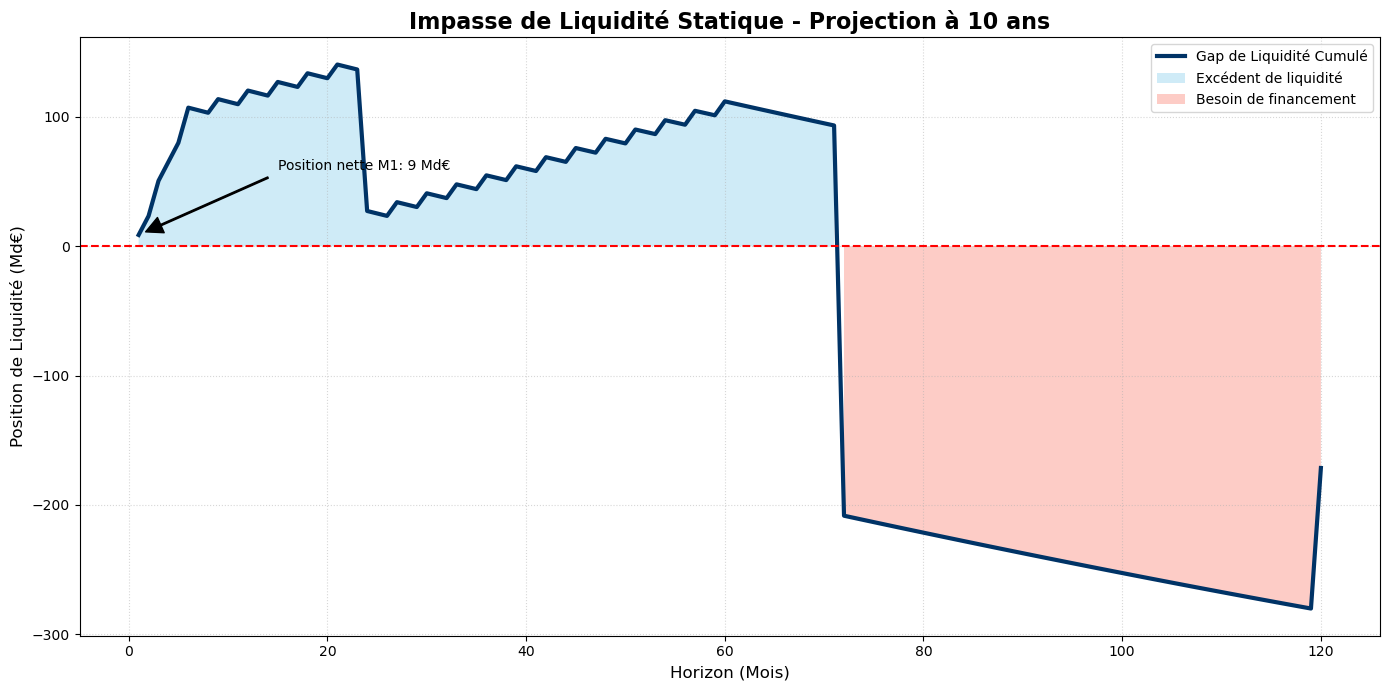

In [32]:
# 1. Calcul du Gap Mensuel : Somme de tous les flux (Actifs - Passifs) pour chaque mois
gap_mensuel = df_flux.sum()

# 2. Calcul du Gap Cumulé : "stock" de liquidité disponible 
gap_cumule = gap_mensuel.cumsum()

# 3. Création du graphique avec Matplotlib
plt.figure(figsize=(14, 7))

# Tracé de la courbe principale
plt.plot(range(1, 121), gap_cumule, color='#003366', linewidth=3, label='Gap de Liquidité Cumulé')

# Remplissage de la zone (Bleu si positif, Rouge si négatif)
plt.fill_between(range(1, 121), gap_cumule, 0, 
                 where=(gap_cumule >= 0), facecolor='skyblue', alpha=0.4, label='Excédent de liquidité')
plt.fill_between(range(1, 121), gap_cumule, 0, 
                 where=(gap_cumule < 0), facecolor='salmon', alpha=0.4, label='Besoin de financement')

# Ajout de la ligne de sécurité à 0
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)

# 4. Habillage (Labels et Titres)
plt.title('Impasse de Liquidité Statique - Projection à 10 ans', fontsize=16, fontweight='bold')
plt.xlabel('Horizon (Mois)', fontsize=12)
plt.ylabel('Position de Liquidité (Md€)', fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend(loc='upper right')

# Ajout d'une annotation pour le point de départ (HQLA)
plt.annotate(f'Position nette M1: {gap_cumule.iloc[0]:.0f} Md€', 
             xy=(1, gap_cumule.iloc[0]), xytext=(15, gap_cumule.iloc[0]+50),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

impasse_min = gap_cumule.min()
mois_critique = gap_cumule.idxmin()

#Mois au plus bas
print(f"Ton point le plus critique est au mois {mois_critique} avec une réserve de {impasse_min:.2f} Md€.")

plt.tight_layout()
plt.show()

Numérateur (HQLA) : 90.00 Md€
Dénominateur (Sorties théoriques stressées) : 192.00 Md€
Ratio LCR final scén2 : 42.19 %


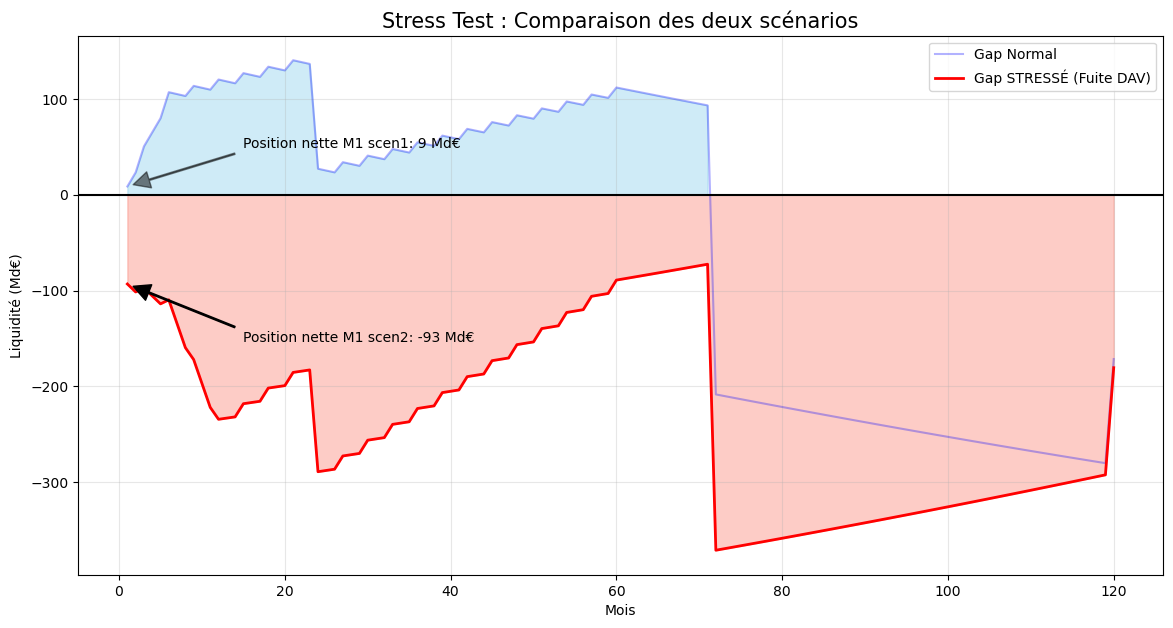

In [42]:
# --- PARAMÈTRES DU STRESS TEST ---
taux_fuite_dav = 0.40  # 40% des dépôts s'en vont au lieu de 20%
choc_hqla = 0.10       # Décote de 10% sur les HQLA en période de stress

hqla = df_bilan.loc[df_bilan['poste_bilan'] == 'HQLA / Cash', 'montant_mde'].values[0]
# --- CALCUL DES FLUX STRESSÉS ---
flux_stress_dict = {}

for nom, flux in flux_dict.items():
    flux_s = flux.copy()
    
# Si c'est un dépôt à vue
    if "DAV" in nom:
# On simule une sortie massive au mois 1
        montant_total = abs(flux.sum())
        flux_s[:] = 0 # On reset
        flux_s[0] = -(montant_total * taux_fuite_dav)
# Le reste s'écoule sur la maturité restante
        reste = -(montant_total * (1 - taux_fuite_dav))
        flux_s[1:12] = reste / 11 
        
# Si c'est du Cash/HQLA (mois 1)
    if "HQLA" in nom:
#On applique la décote de 10%
        flux_s[0] = flux[0] * (1 - choc_hqla)
       
    flux_stress_dict[nom] = flux_s

# DataFrame et Gap Cumulé Stressé
df_flux_stress = pd.DataFrame(flux_stress_dict).T
gap_cumule_stress = df_flux_stress.sum().cumsum()

# --- CALCUL DU LCR (Mois 1) ---
#Numérateur 
hqla_stresse = df_flux_stress.loc[df_flux_stress.index.str.contains('HQLA|CASH', case=False)].iloc[:, 0].sum()

#Dénominateur
sorties_stress_dav = abs(df_bilan[df_bilan['poste_bilan'].str.contains('DAV', case=False)]['montant_mde'].sum()) * taux_fuite_dav

#L'analyse se place dans un cadre de stress immédiat
#Les comptes à terme, modélisés en loi BULLET, sont supposé non éxigibles à CT et ne contribuent donc pas au besoin de financement de liquidité du M1
total_sorties_stress = sorties_stress_dav 

# 3. Ratio Final
lcr_final = (hqla_stresse / total_sorties_stress) * 100

print(f"Numérateur (HQLA) : {hqla:.2f} Md€")
print(f"Dénominateur (Sorties théoriques stressées) : {total_sorties_stress:.2f} Md€")
print(f"Ratio LCR final scén2 : {lcr_final:.2f} %")




# --- GRAPHIQUE DE COMPARAISON ---


plt.figure(figsize=(14, 7))
plt.plot(range(1, 121), gap_cumule, label='Gap Normal', color='blue', alpha=0.3)
plt.plot(range(1, 121), gap_cumule_stress, label='Gap STRESSÉ (Fuite DAV)', color='red', linewidth=2)

plt.annotate(f'Position nette M1 scen1: {gap_cumule.iloc[0]:.0f} Md€', 
             xy=(1, gap_cumule.iloc[0]), 
             xytext=(15, gap_cumule.iloc[0] + 40),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, alpha=0.5))
            

plt.annotate(f'Position nette M1 scen2: {gap_cumule_stress.iloc[0]:.0f} Md€', 
             xy=(1, gap_cumule_stress.iloc[0]), 
             xytext=(15, gap_cumule_stress.iloc[0] - 60), 
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.fill_between(range(1, 121), gap_cumule_stress, 0, where=(gap_cumule_stress < 0), color='salmon', alpha=0.4)
plt.fill_between(range(1, 121), gap_cumule, 0, where=(gap_cumule > 0), color='skyblue', alpha=0.4)
plt.axhline(0, color='black', linestyle='-')
plt.title('Stress Test : Comparaison des deux scénarios', fontsize=15)
plt.xlabel('Mois')
plt.ylabel('Liquidité (Md€)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()





In [23]:
#DEUXIEME PARTIE DU PROJET SIMULATION SENSIBILITE DE LA MNI SUR 1AN
import numpy as np
#SCENARIO 1 +200 bps
#Données SQL
df = pd.read_sql("SELECT * FROM table_bilan", conn)

# 2. On identifie ce qui "reprice" (change de taux) dans les 12 mois
df['reprice_12m'] = np.where((df['type_taux'] == 'V') | (df['maturite_mois'] <= 12),
    df['montant_mde'], 0)

# 3. On sépare Actif et Passif
actif_sensible = df[df['categorie'] == 'ACTIF']['reprice_12m'].sum()
passif_sensible = df[df['categorie'] == 'PASSIF']['reprice_12m'].sum()

# 4. Calcul du Gap de Taux
gap_taux_12m = actif_sensible - passif_sensible

# 5. Simulation du Choc (+200 bps = +0.02)
choc = 0.02
impact_mni = gap_taux_12m * choc

print(f"--- ANALYSE DE SENSIBILITÉ (CHOC +2%) ---")
print(f"Actifs sensibles à 12m : {actif_sensible:.1f} Md€")
print(f"Passifs sensibles à 12m : {passif_sensible:.1f} Md€")
print(f"Gap de Taux : {gap_taux_12m:.1f} Md€") 
print(f"-----------------------------------------")
print(f"IMPACT SUR LA MNI (1 AN) : {impact_mni * 1000:.0f} Millions €")

--- ANALYSE DE SENSIBILITÉ (CHOC +2%) ---
Actifs sensibles à 12m : 440.0 Md€
Passifs sensibles à 12m : 0.0 Md€
Gap de Taux : 440.0 Md€
-----------------------------------------
IMPACT SUR LA MNI (1 AN) : 8800 Millions €


In [24]:
# SCENARIO 2 AVEC UN BETA de 60% et +200bps
choc_marche = 0.02          # +2% 
beta_depots = 0.60          # La banque est forcée de rendre 60% de la hausse aux clients
montant_dav = 480.0         

# 1. Gain sur l'Actif 
# Rappel : HQLA + Equipement + Tresorerie = 440 Md€ sensibles
gain_actif = 440 * choc_marche 

# 2. Coût du Passif "Exigeant"
# Les clients demandent une hausse de (2% * 60%) = 1.2%
hausse_taux_dav = choc_marche * beta_depots
cout_passif = montant_dav * hausse_taux_dav

# 3. Nouvelle Marge Nette d'Intérêt (MNI)
mni_finale = gain_actif - cout_passif

print(f"--- SCÉNARIO CLIENTS EXIGEANTS (Beta {beta_depots*100:.0f}%) ---")
print(f"Gain sur les prêts : +{gain_actif:.2f} Md€")
print(f"Surcoût des dépôts : -{cout_passif:.2f} Md€")
print(f"--------------------------------------------------")
print(f"PROFIT NET FINAL   : {mni_finale * 1000:.0f} Millions €")

if mni_finale < 0:
    print("ALERTE : La banque perd de l'argent à cause de la hausse des taux !")

--- SCÉNARIO CLIENTS EXIGEANTS (Beta 60%) ---
Gain sur les prêts : +8.80 Md€
Surcoût des dépôts : -5.76 Md€
--------------------------------------------------
PROFIT NET FINAL   : 3040 Millions €


MNI calculée avec les données sans choc : 27.04 Md€


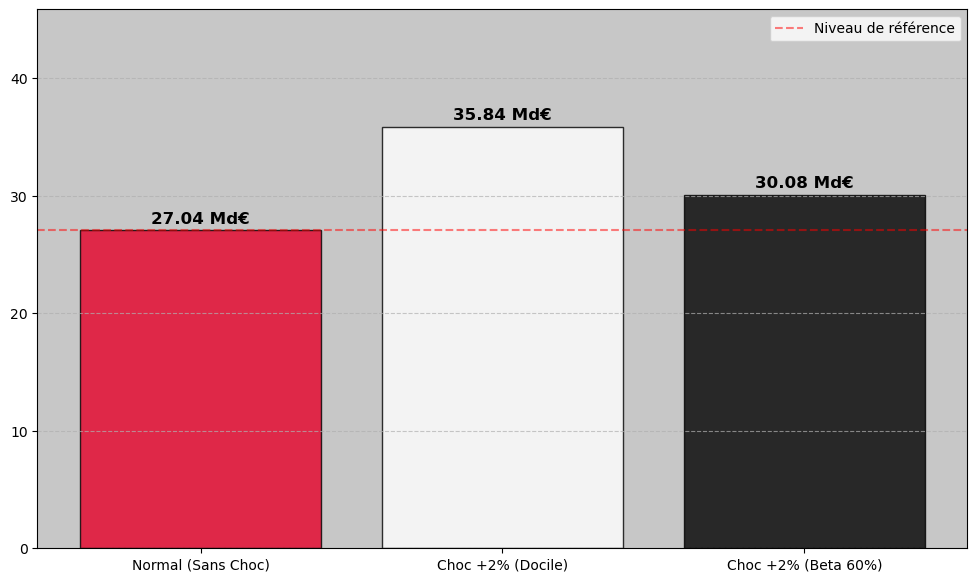

In [25]:
import matplotlib.pyplot as plt
import numpy as np

#3. CALCUL DE LA MNI EN COMPARAISON  AVEC 'SANS CHOC' 

#Revenus de l'Actif
actif = df[df['categorie'] == 'ACTIF']
revenus_annuels = (actif['montant_mde'] * actif['taux']).sum()

#Charges du Passif
passif = df[df['categorie'] == 'PASSIF']
charges_annuelles = (passif['montant_mde'] * passif['taux']).sum()

#MNI de base
mni_base = revenus_annuels - charges_annuelles

# --- CALCUL DES VARIATIONS (CHOCS) ---

impact_docile = gap_taux_12m * 0.02
mni_docile = mni_base + impact_docile

# Impact choc exigeant (+2% actif, +1.2% sur les DAV)
surcout_dav = 480 * (0.02 * 0.60)
mni_exigeante = mni_docile - surcout_dav

print(f"MNI calculée avec les données sans choc : {mni_base:.2f} Md€")


# --- DONNÉES ---
scenarios = ['Normal (Sans Choc)', 'Choc +2% (Docile)', 'Choc +2% (Beta 60%)']
mni_values = [mni_base, mni_docile, mni_exigeante]  

# --- CRÉATION DU GRAPHIQUE ---
plt.close('all')
fig, ax = plt.subplots(figsize=(12, 7))

# Couleurs pour différencier les scénarios
colors = ['#E60028', '#FFFFFF', '#000000']

bars = ax.bar(scenarios, mni_values, color=colors, edgecolor='black', alpha=0.8)

#Valeur au dessus des bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f} Md€',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), 
                textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Habillage
ax.set_ylim(0, max(mni_values) + 10) 

ax.set_facecolor('#C7C7C7')
ax.grid(axis='y', linestyle='--', alpha=0.7)


ax.axhline(mni_base, color='red', linestyle='--', alpha=0.5, label='Niveau de référence')
ax.legend()

plt.show()